# BIODCASE Bioacoustic Classification Pipeline

This notebook documents the complete project pipeline objectively, from raw annotations to model evaluation. It follows the code already present in the repository and is designed to be runnable step by step.

Expensive operations are guarded by `RUN_*` flags. By default, the notebook inspects existing artifacts instead of rebuilding the full manifest, cache, or training run.

## 1. Pipeline Overview

The project has these main stages:

1. Read BIODCASE annotation CSV files and WAV files.
2. Build a clean event manifest with clipped event times and quality filtering.
3. Convert each event into a 3-channel spectrogram tensor.
4. Cache spectrogram tensors on disk to avoid repeated audio preprocessing.
5. Train a ResNet18 classifier using class weighting, optional focal loss, and optional weighted sampling.
6. Evaluate the best checkpoint with global, per-class, per-dataset, confusion, confidence, PR-curve, and baseline reports.
7. Inspect common errors and run inference on individual images or audio events.

In [1]:
from pathlib import Path
import json
import shlex
import subprocess
import sys

import pandas as pd
import yaml

try:
    display
except NameError:
    def display(value):
        print(value)

PROJECT_ROOT = Path.cwd()
PYTHON = shlex.quote(sys.executable)
print(PROJECT_ROOT)
print("python", sys.executable)

# Cost-control switches. Set individual values to True when you want to run that stage.
RUN_BUILD_MANIFEST = False
RUN_CACHE_SUMMARY = True
RUN_SMOKE_TRAINING = False
RUN_FULL_TRAINING = False
RUN_EVALUATION = False
RUN_TESTS = True

def run(command, check=True):
    """Run a shell command from the project root and print stdout/stderr."""
    result = subprocess.run(
        command,
        shell=True,
        cwd=PROJECT_ROOT,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr, file=sys.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {command}")
    return result


/home/odebrino/Documents/ENSTA/ML
python /home/odebrino/Documents/ENSTA/ML/.venv/bin/python


## 2. Repository Layout

The important source folders are:

- `src/data`: manifest creation, spectrogram generation, cache tools, dataset class.
- `src/models`: model factory.
- `src/training`: shared loader logic, losses, train/evaluate/predict scripts.
- `src/utils`: config loading, metrics, seed and audio datetime helpers.
- `src/analysis`: post-training audits and error export helpers.
- `configs`: YAML experiment configurations.
- `tests`: unit tests for utility behavior and reporting.
- `outputs/runs`: training and evaluation artifacts.
- `processed_cache`: cached spectrogram tensors.

In [2]:
for folder in ["src", "configs", "tests", "outputs", "processed_cache", "biodcase_development_set"]:
    path = PROJECT_ROOT / folder
    if path.exists():
        files = sum(1 for item in path.rglob("*") if item.is_file())
        print(f"{folder:28s} files={files}")
    else:
        print(f"{folder:28s} missing")


src                          files=43
configs                      files=8
tests                        files=14
outputs                      files=101
processed_cache              files=76123
biodcase_development_set     files=6602


## 3. Environment And Dependencies

The base dependencies are declared in `requirements.txt`. The CUDA PyTorch stack is declared separately in `requirements-cu124.txt`, and test tooling is in `requirements-dev.txt`.

The project can run on CPU, but the training configs target CUDA by default.

In [3]:
try:
    import torch
    import torchaudio
    import torchvision
    print("torch", torch.__version__)
    print("torchaudio", torchaudio.__version__)
    print("torchvision", torchvision.__version__)
    print("cuda_available", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu", torch.cuda.get_device_name(0))
except Exception as exc:
    print(type(exc).__name__, exc)


torch 2.6.0+cu124
torchaudio 2.6.0+cu124
torchvision 0.21.0+cu124
cuda_available True
gpu NVIDIA GeForce RTX 4060 Laptop GPU


## 4. Configuration Loading

YAML files can inherit from another YAML file through an `extends` key. The loader recursively merges parent and child configs, so experiment files only need to override changed values.

In [4]:
from src.utils.config import load_config

CONFIG_PATH = PROJECT_ROOT / "configs" / "nitro4060_bpd.yaml"
config = load_config(CONFIG_PATH)

print("config:", CONFIG_PATH)
print("classes:", config["classes"])
print("model:", config["model"])
print("training:")
print(yaml.safe_dump(config["training"], sort_keys=False))


config: /home/odebrino/Documents/ENSTA/ML/configs/nitro4060_bpd.yaml
classes: ['bma', 'bmb', 'bmd', 'bmz', 'bp20', 'bp20plus', 'bpd']
model: {'name': 'resnet18', 'pretrained': False, 'img_size': 224}
training:
device: cuda
seed: 42
batch_size: 64
epochs: 15
lr: 0.0001
weight_decay: 0.0001
num_workers: 4
pin_memory: true
persistent_workers: true
mixed_precision: true
compile_model: false
grad_clip_norm: 2.0
sampler: none
loss:
  name: focal
  gamma: 2.0
class_weight_multipliers:
  bpd: 2.0
  bmz: 1.35
use_class_weights: true
early_stopping_patience: 5
output_dir: outputs/runs



## 5. Manifest Creation

`src.data.build_manifest` reads all annotation CSV files for the requested splits. For each annotation row, it:

- verifies required columns;
- resolves the corresponding WAV path;
- removes duplicate events;
- reads real WAV duration;
- converts annotation datetimes to seconds relative to the WAV start time;
- clips event boundaries to available audio;
- discards events that start after audio end or contain less than the configured valid duration;
- writes a clean manifest and quality reports.

The default clean manifest is `data_manifest.csv`.

In [5]:
if RUN_BUILD_MANIFEST:
    run(
        f"{PYTHON} -m src.data.build_manifest "
        "--data-root biodcase_development_set "
        "--out data_manifest.csv "
        "--quality-report outputs/data_quality_report.csv "
        "--quality-summary outputs/data_quality_summary.csv "
        "--min-valid-seconds 0.5"
    )
else:
    print("Skipped manifest rebuild. Using existing data_manifest.csv if present.")


Skipped manifest rebuild. Using existing data_manifest.csv if present.


In [6]:
manifest_path = PROJECT_ROOT / "data_manifest.csv"
manifest = pd.read_csv(manifest_path)

print("rows", len(manifest))
print("columns", list(manifest.columns))
display(manifest.head())


rows 76123
columns ['split', 'dataset', 'filename', 'audio_path', 'label', 'annotator', 'low_frequency', 'high_frequency', 'start_datetime', 'end_datetime', 'start_seconds', 'end_seconds', 'clip_start_seconds', 'clip_end_seconds', 'duration_seconds', 'real_duration_seconds', 'audio_duration_seconds', 'valid_event', 'quality_status', 'source_annotation', 'source_row']


,split,dataset,filename,audio_path,label,annotator,low_frequency,high_frequency,start_datetime,end_datetime,...,end_seconds,clip_start_seconds,clip_end_seconds,duration_seconds,real_duration_seconds,audio_duration_seconds,valid_event,quality_status,source_annotation,source_row
0,train,ballenyislands2015,2015-02-04T03-00-00_000.wav,biodcase_development_set/train/audio/ballenyis...,bma,nieukirk,21.9,28.4,2015-02-04T03:27:32.053000+00:00,2015-02-04T03:27:43.709000+00:00,...,1663.709,1652.053,1663.709,11.656,11.656,3600.004,True,ok,biodcase_development_set/train/annotations/bal...,0
1,train,ballenyislands2015,2015-02-16T11-00-00_000.wav,biodcase_development_set/train/audio/ballenyis...,bma,nieukirk,22.4,27.3,2015-02-16T11:54:10.436000+00:00,2015-02-16T11:54:16.414000+00:00,...,3256.414,3250.436,3256.414,5.978,5.978,3600.004,True,ok,biodcase_development_set/train/annotations/bal...,1
2,train,ballenyislands2015,2015-02-16T11-00-00_000.wav,biodcase_development_set/train/audio/ballenyis...,bma,nieukirk,24.5,27.3,2015-02-16T11:52:24.753000+00:00,2015-02-16T11:52:29.236000+00:00,...,3149.236,3144.753,3149.236,4.483,4.483,3600.004,True,ok,biodcase_development_set/train/annotations/bal...,2
3,train,ballenyislands2015,2015-02-16T11-00-00_000.wav,biodcase_development_set/train/audio/ballenyis...,bma,nieukirk,24.2,27.6,2015-02-16T11:50:47.251000+00:00,2015-02-16T11:50:53.004000+00:00,...,3053.004,3047.251,3053.004,5.753,5.753,3600.004,True,ok,biodcase_development_set/train/annotations/bal...,3
4,train,ballenyislands2015,2015-02-20T00-00-00_000.wav,biodcase_development_set/train/audio/ballenyis...,bma,nieukirk,22.7,27.3,2015-02-20T00:38:36.379000+00:00,2015-02-20T00:38:44.225000+00:00,...,2324.225,2316.379,2324.225,7.846,7.846,3600.004,True,ok,biodcase_development_set/train/annotations/bal...,4


## 6. Split, Class, And Dataset Distributions

The project uses the dataset-provided `train` and `validation` directories. It does not create a random stratified split. This matters because validation contains different datasets from training, so validation measures domain transfer as well as classification accuracy.

In [7]:
print("Rows per split")
display(manifest["split"].value_counts().sort_index().rename("count"))

print("Labels by split")
display(pd.crosstab(manifest["label"], manifest["split"]))

print("Datasets by split")
display(pd.crosstab(manifest["dataset"], manifest["split"]))

print("Quality status")
display(manifest["quality_status"].value_counts(dropna=False).rename("count"))


Rows per split


split
train         58510
validation    17613
Name: count, dtype: int64

Labels by split


split,train,validation
label,,
bma,18092,6268
bmb,4622,2277
bmd,13141,2168
bmz,1596,918
bp20,10380,2547
bp20plus,5003,2757
bpd,5676,678


Datasets by split


split,train,validation
dataset,,
ballenyislands2015,2222,0
casey2014,6866,0
casey2017,0,3263
elephantisland2013,21913,0
elephantisland2014,20957,0
greenwich2015,1128,0
kerguelen2005,2960,0
kerguelen2014,0,8814
kerguelen2015,0,5536


Quality status


quality_status
ok             76052
clipped_end       71
Name: count, dtype: int64

In [8]:
quality_summary_path = PROJECT_ROOT / "outputs" / "data_quality_summary.csv"
quality_report_path = PROJECT_ROOT / "outputs" / "data_quality_report.csv"

if quality_summary_path.exists():
    quality_summary = pd.read_csv(quality_summary_path)
    print("Quality summary rows", len(quality_summary))
    display(quality_summary)

if quality_report_path.exists():
    quality_report = pd.read_csv(quality_report_path)
    print("Quality report rows", len(quality_report))
    display(quality_report.head(20))


Quality summary rows 12


,issue,split,dataset,label,count
0,duplicate_event,validation,kerguelen2015,bp20plus,1
1,start_after_audio_end,train,elephantisland2014,bma,5
2,too_little_audio,train,elephantisland2013,bmb,3
3,too_little_audio,train,elephantisland2013,bmd,30
4,too_little_audio,train,elephantisland2013,bmz,1
5,too_little_audio,train,elephantisland2013,bp20,2
6,too_little_audio,train,elephantisland2013,bpd,17
7,too_little_audio,train,elephantisland2014,bmb,1
8,too_little_audio,train,elephantisland2014,bp20,1
9,too_little_audio,validation,kerguelen2014,bp20,3


Quality report rows 74


,split,dataset,filename,label,source,row,issue,start_seconds,end_seconds,audio_duration_seconds,real_duration_seconds
0,train,elephantisland2013,2013-02-17T02-00-00_000.wav,bmb,biodcase_development_set/train/annotations/ele...,2849,too_little_audio,299.959,308.346,300.0,0.041
1,train,elephantisland2013,2013-03-07T01-00-00_000.wav,bmb,biodcase_development_set/train/annotations/ele...,3485,too_little_audio,299.655,309.274,300.0,0.345
2,train,elephantisland2013,2013-02-27T12-00-00_000.wav,bmb,biodcase_development_set/train/annotations/ele...,4122,too_little_audio,299.677,306.058,300.0,0.323
3,train,elephantisland2013,2013-02-23T19-00-00_000.wav,bmz,biodcase_development_set/train/annotations/ele...,4497,too_little_audio,299.732,312.303,300.0,0.268
4,train,elephantisland2013,2013-02-16T12-00-00_000.wav,bmd,biodcase_development_set/train/annotations/ele...,7901,too_little_audio,191.332,191.762,300.0,0.430
5,train,elephantisland2013,2013-02-17T10-00-00_000.wav,bmd,biodcase_development_set/train/annotations/ele...,8076,too_little_audio,245.485,245.808,300.0,0.323
6,train,elephantisland2013,2013-02-23T21-00-00_000.wav,bmd,biodcase_development_set/train/annotations/ele...,8960,too_little_audio,157.255,157.731,300.0,0.476
7,train,elephantisland2013,2013-02-23T21-00-00_000.wav,bmd,biodcase_development_set/train/annotations/ele...,8964,too_little_audio,172.492,172.968,300.0,0.476
8,train,elephantisland2013,2013-02-26T20-00-00_000.wav,bmd,biodcase_development_set/train/annotations/ele...,9550,too_little_audio,254.681,254.967,300.0,0.286
9,train,elephantisland2013,2013-02-27T13-00-00_000.wav,bmd,biodcase_development_set/train/annotations/ele...,9684,too_little_audio,26.060,26.536,300.0,0.476


## 7. Spectrogram Tensor Construction

Each valid event is converted from audio to a fixed-size tensor in `src.data.spectrogram`.

Processing steps:

1. Load the WAV file.
2. Resample to the configured sample rate if necessary.
3. Convert multi-channel audio to mono.
4. Crop the event with a configurable time margin.
5. Compute a mel spectrogram and convert amplitude to decibels.
6. Normalize either per sample or with configured global dB bounds.
7. Resize to `model.img_size`.
8. Build a frequency mask from annotation low/high frequency.
9. Stack three channels: full spectrogram, mask, highlighted spectrogram.

Because the model receives the annotation frequency band as input, inference is designed for already localized/annotated events, not arbitrary unsegmented raw audio.

In [9]:
from src.data.spectrogram import event_tensor

sample_row = manifest[manifest["split"] == config.get("val_split", "validation")].iloc[0].to_dict()
print({key: sample_row[key] for key in ["split", "dataset", "filename", "label", "low_frequency", "high_frequency"]})

tensor = event_tensor(sample_row, config["audio"], int(config["model"]["img_size"]))
print("tensor shape", tuple(tensor.shape))
print("min", float(tensor.min()), "max", float(tensor.max()), "dtype", tensor.dtype)


{'split': 'validation', 'dataset': 'casey2017', 'filename': '2016-12-16T08-00-00_000.wav', 'label': 'bma', 'low_frequency': 22.1, 'high_frequency': 28.9}
tensor shape (3, 224, 224)
min 0.0 max 1.0 dtype torch.float32


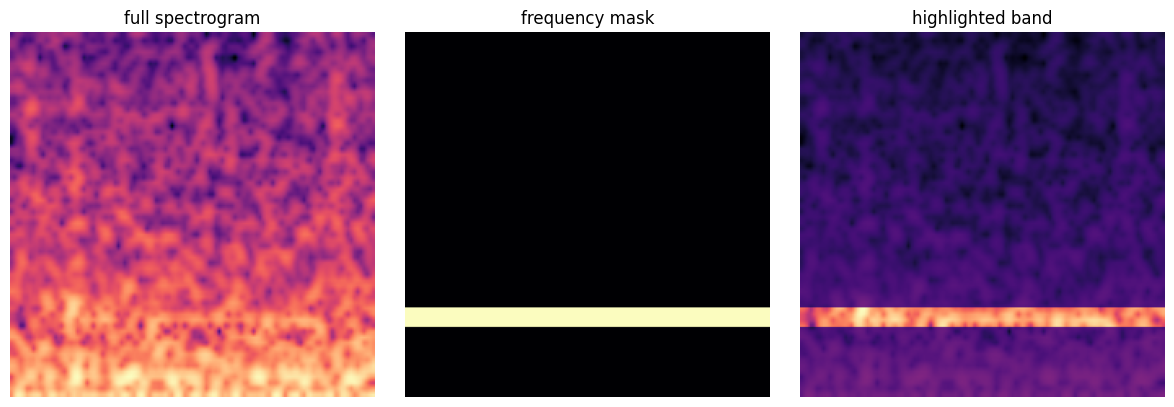

In [10]:
import matplotlib.pyplot as plt

titles = ["full spectrogram", "frequency mask", "highlighted band"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, channel, title in zip(axes, tensor, titles):
    axis.imshow(channel.numpy(), cmap="magma", origin="upper")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()


## 8. Tensor Cache

`cached_event_tensor` stores generated event tensors under `processed_cache/<split>/<label>/<hash>.pt`.

The cache key includes transform version, dtype, split, dataset, filename, audio path, audio file size, audio modification time, event times, frequency band, audio config, and image size. This invalidates stale cache entries when audio files or preprocessing settings change.

In [11]:
if RUN_CACHE_SUMMARY:
    run(f"{PYTHON} -m src.data.cache_tools --summary")
else:
    print("Skipped cache summary.")


root: processed_cache
files: 76123
size_gb: 21.45



## 9. Dataset And DataLoader

`BioacousticDataset` filters the manifest by split, validates labels against the configured class list, loads image tensors or spectrogram tensors, and returns `(tensor, label_index, metadata)`.

`create_loader` wraps the dataset in a PyTorch DataLoader. For training, it can optionally use `WeightedRandomSampler` based on inverse class frequency and configured class multipliers.

In [12]:
from src.data.dataset import BioacousticDataset

dataset = BioacousticDataset(
    manifest_path=manifest_path,
    split=config.get("val_split", "validation"),
    class_names=config["classes"],
    img_size=int(config["model"]["img_size"]),
    audio_cfg=config["audio"],
    train=False,
    mode=config.get("dataset", {}).get("mode", "spectrogram"),
    cache_cfg=None,
)

print("dataset length", len(dataset))
print("class counts", dict(zip(config["classes"], dataset.class_counts())))
x, y, meta = dataset[0]
print("sample tensor", tuple(x.shape), "label index", y, "label", config["classes"][y])
print("metadata keys", sorted(meta.keys()))


dataset length 17613
class counts {'bma': 6268, 'bmb': 2277, 'bmd': 2168, 'bmz': 918, 'bp20': 2547, 'bp20plus': 2757, 'bpd': 678}
sample tensor (3, 224, 224) label index 0 label bma
metadata keys ['audio_path', 'clip_end_seconds', 'clip_start_seconds', 'dataset', 'duration_seconds', 'filename', 'high_frequency', 'label', 'low_frequency', 'real_duration_seconds', 'source_row']


## 10. Model

The model factory currently supports `resnet18`. It uses torchvision's ResNet18 and replaces the final fully connected layer with `num_classes` outputs.

The first convolution is unchanged, which matches the 3-channel spectrogram tensor.

In [13]:
from src.models.resnet import create_model

model = create_model(
    name=config["model"]["name"],
    num_classes=len(config["classes"]),
    pretrained=bool(config["model"].get("pretrained", False)),
)
print(model.__class__.__name__)
print("final layer", model.fc)


ResNet
final layer Linear(in_features=512, out_features=7, bias=True)


## 11. Training

`src.training.train` performs the training loop.

Main operations:

- set random seeds;
- select CUDA if requested and available, otherwise CPU;
- create a timestamped run directory;
- save the resolved config;
- create train and validation loaders;
- create the ResNet18 classifier;
- compute class weights from train-set class counts;
- optionally apply class-specific multipliers;
- choose cross-entropy or focal loss;
- optimize with AdamW;
- reduce learning rate on validation macro-F1 plateau;
- use automatic mixed precision on CUDA;
- save best and last checkpoints;
- run final evaluation for the best checkpoint.

The notebook does not run full training unless `RUN_FULL_TRAINING = True`.

In [14]:
if RUN_SMOKE_TRAINING:
    run(f"{PYTHON} -m src.training.train --config configs/smoke.yaml --manifest data_manifest.csv")
elif RUN_FULL_TRAINING:
    run(f"{PYTHON} -m src.training.train --config configs/nitro4060_bpd.yaml --manifest data_manifest.csv")
else:
    print("Skipped training. Existing runs can be inspected in outputs/runs/.")


Skipped training. Existing runs can be inspected in outputs/runs/.


## 12. Existing Runs

Each run directory may contain checkpoints, config copy, history, metrics, predictions, confusion matrices, and error reports.

In [15]:
runs_root = PROJECT_ROOT / "outputs" / "runs"
run_rows = []
for metrics_path in sorted(runs_root.glob("*/best_metrics.json")):
    metrics = json.loads(metrics_path.read_text())
    run_rows.append({
        "run": metrics_path.parent.name,
        "accuracy": metrics.get("accuracy"),
        "balanced_accuracy": metrics.get("balanced_accuracy"),
        "macro_f1": metrics.get("macro_f1"),
        "weighted_f1": metrics.get("weighted_f1"),
    })

runs = pd.DataFrame(run_rows).sort_values("macro_f1", ascending=False)
display(runs)
best_run = runs.iloc[0]["run"] if len(runs) else None
print("best run by macro_f1", best_run)


,run,accuracy,balanced_accuracy,macro_f1,weighted_f1
3,20260421-223457,0.930052,0.902237,0.886624,0.930905
5,20260422-205305,0.927610,0.904834,0.879364,0.929152
2,20260421-213619,0.932323,NaN,0.859282,0.926737
4,20260422-193846,0.905922,NaN,0.772548,0.894325
1,20260421-212459,0.142857,NaN,0.035714,0.035714
0,20260421-210938,0.142857,NaN,0.035714,0.035714


best run by macro_f1 20260421-223457


## 13. Evaluation

`src.training.evaluate` loads a checkpoint, runs inference over the selected split, and writes:

- `best_metrics.json`;
- `classification_report.csv`;
- `metrics_by_dataset.csv`;
- `metrics_by_dataset_class.csv`;
- `baseline_metrics.csv`;
- `class_confidence_analysis.csv`;
- `pr_curves.csv`;
- `error_analysis.csv`;
- `top_confusion_pairs.csv`;
- focused error reports for `bpd/bmd` and `bmb/bmz`;
- confusion matrix CSV and PNG files;
- `val_predictions.csv` with one row per evaluated event.

The main global metric is macro-F1. Per-dataset reports include `macro_f1_present_classes`, which ignores classes absent from a dataset.

In [16]:
if RUN_EVALUATION and best_run:
    checkpoint = runs_root / best_run / "best_model.pt"
    output_dir = runs_root / best_run
    run(
        f"{PYTHON} -m src.training.evaluate "
        f"--checkpoint {checkpoint} "
        f"--config configs/nitro4060_bpd.yaml "
        f"--manifest data_manifest.csv "
        f"--output-dir {output_dir}"
    )
else:
    print("Skipped evaluation. Existing evaluation files are inspected below.")


Skipped evaluation. Existing evaluation files are inspected below.


In [17]:
if best_run:
    best_dir = runs_root / best_run
    metrics = json.loads((best_dir / "best_metrics.json").read_text())
    print("run", best_run)
    for key in ["accuracy", "balanced_accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]:
        if key in metrics:
            print(f"{key:22s} {metrics[key]:.4f}")

    report = pd.read_csv(best_dir / "classification_report.csv")
    display(report[report["label"].isin(config["classes"])])

    dataset_metrics_path = best_dir / "metrics_by_dataset.csv"
    if dataset_metrics_path.exists():
        display(pd.read_csv(dataset_metrics_path))


run 20260421-223457
accuracy               0.9301
balanced_accuracy      0.9022
macro_precision        0.8817
macro_recall           0.9022
macro_f1               0.8866
weighted_f1            0.9309


,label,precision,recall,f1-score,support,score
0,bma,0.982773,0.964742,0.973674,6268.0,NaN
1,bmb,0.860477,0.728590,0.789061,2277.0,NaN
2,bmd,0.922834,0.943266,0.932938,2168.0,NaN
3,bmz,0.631004,0.944444,0.756545,918.0,NaN
4,bp20,0.983353,0.997252,0.990253,2547.0,NaN
5,bp20plus,0.999263,0.983678,0.991409,2757.0,NaN
6,bpd,0.792248,0.753687,0.772487,678.0,NaN


,dataset,support,accuracy,macro_f1,macro_f1_present_classes,weighted_f1
0,casey2017,3263,0.926755,0.764244,0.891619,0.930978
1,kerguelen2014,8814,0.931700,0.890416,0.890416,0.933451
2,kerguelen2015,5536,0.929371,0.890968,0.890968,0.929912


## 14. Error Analysis

`error_analysis.csv` counts true-label/predicted-label pairs for misclassified events. Focused reports isolate error families that were important in the experiments, especially `bpd` versus `bmd` and `bmb` versus `bmz`.

In [18]:
if best_run:
    best_dir = runs_root / best_run
    for name in ["error_analysis.csv", "bpd_error_report.csv", "bmb_bmz_error_report.csv", "baseline_metrics.csv", "class_confidence_analysis.csv"]:
        path = best_dir / name
        if path.exists():
            print(name)
            display(pd.read_csv(path).head(15))


error_analysis.csv


,y_true_label,y_pred_label,count
0,bmb,bmz,504
1,bma,bmb,218
2,bpd,bmd,167
3,bmd,bpd,122
4,bmb,bma,106
5,bmz,bmb,51
6,bp20plus,bp20,40
7,bp20,bpd,7
8,bp20plus,bpd,5
9,bmb,bmd,4


bpd_error_report.csv


,dataset,filename,source_row,y_true_label,y_pred_label,pred_confidence,true_probability,low_frequency,high_frequency,duration_seconds,real_duration_seconds,clip_start_seconds,clip_end_seconds,audio_path
0,casey2017,2017-05-10T09-00-00_000.wav,2940,bmd,bpd,0.888736,0.111153,53.8,70.1,2.459,2.459,2727.737,2730.196,biodcase_development_set/validation/audio/case...
1,kerguelen2015,2015-03-14T05-00-00_000.wav,5347,bpd,bmd,0.857185,0.142716,38.1,71.6,1.104,1.104,1155.537,1156.641,biodcase_development_set/validation/audio/kerg...
2,kerguelen2015,2015-03-10T17-00-00_000.wav,2878,bmd,bpd,0.818186,0.179530,32.0,64.4,4.176,4.176,2871.346,2875.522,biodcase_development_set/validation/audio/kerg...
3,kerguelen2015,2015-03-12T11-00-00_000.wav,5313,bpd,bmd,0.814296,0.185355,36.3,75.1,1.196,1.196,3058.295,3059.491,biodcase_development_set/validation/audio/kerg...
4,kerguelen2015,2015-03-16T00-00-00_000.wav,2947,bmd,bpd,0.795405,0.204414,55.9,83.1,1.474,1.474,3187.174,3188.648,biodcase_development_set/validation/audio/kerg...
5,kerguelen2015,2015-03-16T00-00-00_000.wav,2938,bmd,bpd,0.789904,0.210024,51.9,73.9,2.579,2.579,61.738,64.317,biodcase_development_set/validation/audio/kerg...
6,kerguelen2014,2014-03-25T01-00-00_000.wav,8534,bpd,bmd,0.787975,0.211761,40.3,72.8,1.172,1.172,1983.504,1984.676,biodcase_development_set/validation/audio/kerg...
7,kerguelen2014,2014-03-25T01-00-00_000.wav,8487,bpd,bmd,0.784453,0.215508,51.1,78.1,1.932,1.932,776.384,778.316,biodcase_development_set/validation/audio/kerg...
8,kerguelen2015,2015-04-15T00-00-00_000.wav,3518,bmd,bpd,0.779765,0.215817,25.9,49.3,2.334,2.334,3376.795,3379.129,biodcase_development_set/validation/audio/kerg...
9,kerguelen2014,2014-03-25T01-00-00_000.wav,8491,bpd,bmd,0.777782,0.222102,45.9,81.5,1.757,1.757,1110.170,1111.927,biodcase_development_set/validation/audio/kerg...


bmb_bmz_error_report.csv


,dataset,filename,source_row,y_true_label,y_pred_label,pred_confidence,true_probability,low_frequency,high_frequency,duration_seconds,real_duration_seconds,clip_start_seconds,clip_end_seconds,audio_path
0,casey2017,2017-03-02T10-00-00_000.wav,1853,bmb,bmz,0.972953,0.016030,17.0,28.7,17.525,17.525,1995.827,2013.352,biodcase_development_set/validation/audio/case...
1,casey2017,2017-05-21T00-00-00_000.wav,2073,bmb,bmz,0.945928,0.044443,16.4,28.0,13.706,13.706,379.438,393.144,biodcase_development_set/validation/audio/case...
2,casey2017,2017-05-12T04-00-00_000.wav,2295,bmb,bmz,0.898292,0.098196,16.9,28.0,10.515,10.515,832.577,843.092,biodcase_development_set/validation/audio/case...
3,casey2017,2017-02-28T15-00-00_000.wav,1839,bmb,bmz,0.891794,0.101029,18.0,28.1,12.764,12.764,2377.729,2390.493,biodcase_development_set/validation/audio/case...
4,casey2017,2017-04-20T22-00-00_000.wav,1997,bmb,bmz,0.881294,0.111478,16.4,28.6,10.096,10.096,3558.959,3569.055,biodcase_development_set/validation/audio/case...
5,casey2017,2017-05-21T00-00-00_000.wav,2078,bmb,bmz,0.796224,0.191914,16.2,27.5,12.137,12.137,1471.561,1483.698,biodcase_development_set/validation/audio/case...
6,casey2017,2017-05-10T09-00-00_000.wav,2280,bmb,bmz,0.789070,0.206759,16.4,28.0,10.829,10.829,932.728,943.557,biodcase_development_set/validation/audio/case...
7,casey2017,2017-04-19T04-00-00_000.wav,1949,bmb,bmz,0.777408,0.164491,17.7,28.0,14.857,14.857,224.061,238.918,biodcase_development_set/validation/audio/case...
8,casey2017,2017-05-17T11-00-00_000.wav,2291,bmb,bmz,0.707573,0.285695,15.1,27.8,9.364,9.364,995.157,1004.521,biodcase_development_set/validation/audio/case...
9,casey2017,2017-02-28T15-00-00_000.wav,1837,bmb,bmz,0.707378,0.263461,18.5,28.1,10.986,10.986,2110.318,2121.304,biodcase_development_set/validation/audio/case...


baseline_metrics.csv


,baseline,accuracy,balanced_accuracy,macro_f1,weighted_f1,min_class_recall
0,majority_class,0.355874,0.142857,0.074991,0.186811,0.000000
1,stratified_random_seed0,0.208198,0.142468,0.142468,0.208198,0.038348


class_confidence_analysis.csv


,label,support,accuracy,mean_true_probability,median_true_probability,mean_pred_confidence
0,bma,6268,0.964742,0.780810,0.808438,0.787703
1,bmb,2277,0.728590,0.648234,0.743223,0.779835
2,bmd,2168,0.943266,0.783833,0.821399,0.794344
3,bmz,918,0.944444,0.887093,0.959910,0.913054
4,bp20,2547,0.997252,0.981336,0.990063,0.982531
5,bp20plus,2757,0.983678,0.974472,0.992578,0.989961
6,bpd,678,0.753687,0.585764,0.594332,0.627746


## 15. Inference

`src.training.predict` supports two inference modes:

- image mode: classify an already generated RGB spectrogram image;
- audio mode: classify one WAV event using start/end seconds and low/high frequency metadata.

Audio mode follows the same tensor construction as training.

In [19]:
if best_run:
    example = manifest[manifest["split"] == config.get("val_split", "validation")].iloc[0]
    command = (
        f"{PYTHON} -m src.training.predict "
        f"--checkpoint outputs/runs/{best_run}/best_model.pt "
        f"--config configs/nitro4060_bpd.yaml "
        f"--audio '{example.audio_path}' "
        f"--start-seconds {example.clip_start_seconds} "
        f"--end-seconds {example.clip_end_seconds} "
        f"--low-frequency {example.low_frequency} "
        f"--high-frequency {example.high_frequency}"
    )
    print(command)
    print("Set and run this command in a terminal or call run(command) here to execute inference.")


/home/odebrino/Documents/ENSTA/ML/.venv/bin/python -m src.training.predict --checkpoint outputs/runs/20260421-223457/best_model.pt --config configs/nitro4060_bpd.yaml --audio 'biodcase_development_set/validation/audio/casey2017/2016-12-16T08-00-00_000.wav' --start-seconds 146.584 --end-seconds 152.004 --low-frequency 22.1 --high-frequency 28.9
Set and run this command in a terminal or call run(command) here to execute inference.


## 16. Analysis Utilities

The repository includes two post-training utilities:

- `src.analysis.imbalance_audit`: audits class imbalance, leakage, baselines, and report completeness.
- `src.analysis.inspect_errors`: exports PNG visualizations for selected error-report rows.

These scripts consume artifacts produced by evaluation.

In [20]:
print("Imbalance audit command:")
print(f"{PYTHON} -m src.analysis.imbalance_audit --config configs/nitro4060_bpd.yaml --manifest data_manifest.csv --run-dir outputs/runs/<run>")

print("\nError PNG export command:")
print(f"{PYTHON} -m src.analysis.inspect_errors --report outputs/runs/<run>/bpd_error_report.csv --config configs/nitro4060_bpd.yaml --out outputs/error_samples/<run>")


Imbalance audit command:
/home/odebrino/Documents/ENSTA/ML/.venv/bin/python -m src.analysis.imbalance_audit --config configs/nitro4060_bpd.yaml --manifest data_manifest.csv --run-dir outputs/runs/<run>

Error PNG export command:
/home/odebrino/Documents/ENSTA/ML/.venv/bin/python -m src.analysis.inspect_errors --report outputs/runs/<run>/bpd_error_report.csv --config configs/nitro4060_bpd.yaml --out outputs/error_samples/<run>


## 17. Tests

The test suite verifies objective behavior for config inheritance, audio datetime parsing, manifest filtering, metric handling for absent classes, cache invalidation, focal loss, weighted sampling, and evaluation report writers.

In [21]:
if RUN_TESTS:
    run(f"{PYTHON} -m pytest -q")
else:
    print("Skipped tests.")


.............                                                            [100%]
13 passed in 3.04s



## 18. Current Objective Summary

Based on the existing project artifacts:

- The manifest contains all valid events used by training and validation.
- Training and validation are separated by dataset source, not by random stratification.
- The best documented run is selected by macro-F1.
- The strongest recurring error families are visible in `error_analysis.csv`.
- Cache size should be monitored because one cached tensor is stored per manifest event and transform setting.
- The frequency-band metadata is part of the model input, so deployment assumptions must include event localization and frequency bounds.